In [1]:
import cooltools
import cooler
from tqdm import tqdm
from os.path import basename, splitext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections.abc import Iterable
import bioframe
import gc
import subprocess
import itertools
import pysam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import seaborn as sns

### Load Hi-C cool files (50kb resolution)

In [2]:
wt_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_WT_50k.cool')
old_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_old_50k.cool')
ko_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_50k/balsampled_KO_50k.cool')

CLRS = [wt_clr, old_clr, ko_clr]
LBLS = ['Adult', 'Old', 'S6-KO']

ref_fasta = ('GRCm38.p6.genome.fa')

### Define parameters and calculate DLR and ICF

In [3]:
# Set parameters
split_dist = 10_500_000
logdlr = True
exclude_chromosomes = ['chrM', 'chrX', 'chrY']

DLR = pd.DataFrame()
ICF = pd.DataFrame()

for clr, lbl in zip(CLRS, LBLS):
    # Check chromosome sizes
    if np.any(clr.chromsizes < split_dist):
        raise ValueError("Split distance must be less than the least chromosome size")
    
    # Get pixels and bins
    bins = clr.bins()[:]
    pix = clr.pixels()[:]
    
    # Annotate pixels with bin information
    tbl = cooler.annotate(pix, bins, replace=False)
    
    # Filter chromosomes 
    tbl = tbl[~tbl['chrom1'].isin(exclude_chromosomes) & ~tbl['chrom2'].isin(exclude_chromosomes)]
    
    # Split interactions
    cis_mask = tbl['chrom1'] == tbl['chrom2']
    tbl_cis = tbl[cis_mask].copy()  
    tbl_trs = tbl[~cis_mask].copy()
    
    # Calculate distances for cis interactions
    tbl_cis['distance'] = tbl_cis['start2'] - tbl_cis['start1']
    
    # Split cis by distance
    tbl_cis_loc = tbl_cis[tbl_cis['distance'] <= split_dist]
    tbl_cis_far = tbl_cis[tbl_cis['distance'] > split_dist]
    
    # Sum counts 
    sum_cis_loc = tbl_cis_loc.groupby('bin1_id')['count'].sum()
    sum_cis_far = tbl_cis_far.groupby('bin1_id')['count'].sum()
    sum_cis = sum_cis_loc.add(sum_cis_far, fill_value=0)
    sum_trs = tbl_trs.groupby('bin1_id')['count'].sum()
    
    # Calculate metrics
    with np.errstate(divide='ignore', invalid='ignore'):
        icf = sum_trs / (sum_cis + sum_trs)
        dlr = sum_cis_far / sum_cis_loc
    
        icf = icf.replace([np.inf, -np.inf], np.nan)
        dlr = dlr.replace([np.inf, -np.inf], np.nan)
    
    if logdlr:
        DLR = pd.concat([DLR, np.log10(dlr).rename(lbl)], axis=1)
    else:
        DLR = pd.concat([DLR, dlr.rename(lbl)], axis=1)
    ICF = pd.concat([ICF, icf.rename(lbl)], axis=1)

DLR = DLR.dropna()  
ICF = ICF.dropna()

In [4]:
DLR.head(5)

,Adult,Old,S6-KO
60,-0.318591,-0.359309,-0.266971
61,-0.261194,-0.305436,-0.200841
62,-0.227862,-0.285580,-0.172859
63,-0.162025,-0.230054,-0.140458
64,-0.096824,-0.181072,-0.075166


In [5]:
ICF.head(5)

,Adult,Old,S6-KO
60,0.226822,0.187400,0.203499
61,0.268926,0.215987,0.218851
62,0.256304,0.214146,0.231906
63,0.268070,0.230243,0.248578
64,0.276891,0.256287,0.255633


In [6]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


### Calculate differences and ratios between conditions

In [7]:
%%R
library(reticulate)

dlr <- reticulate::py_eval('DLR')
icf <- reticulate::py_eval('ICF')

old_adl_DLR_diff <- dlr$Old - dlr$Adult
ko_adl_DLR_diff <- dlr$'S6-KO' - dlr$Adult

old_adl_ICF_ratio <- icf$Old / icf$Adult
ko_adl_ICF_ratio <- icf$'S6-KO' / icf$Adult


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages


### Plot the DLR differences

Need help? Try Stackoverflow: https://stackoverflow.com/tags/ggplot2
In addition: Warning messages:
1: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
2: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


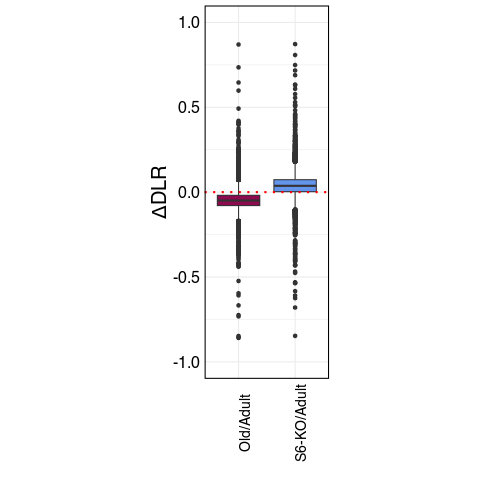

In [9]:
%%R
library(ggplot2)

DLR_diff <- c(old_adl_DLR_diff, ko_adl_DLR_diff)
type <- c(rep('Old/Adult', length(old_adl_DLR_diff)), rep('S6-KO/Adult', length(ko_adl_DLR_diff)))

dlr_diff <- data.frame(DLR_diff, type)
dlr_diff$type <- factor(dlr_diff$type, levels=c('Old/Adult', 'S6-KO/Adult'))


p <- ggplot(dlr_diff, aes(x = type, y = DLR_diff, fill = type)) +
  geom_boxplot() +
  ylim(-1,1) +
  xlab('') + ylab(expression(Delta * "DLR")) +
  geom_hline(yintercept=0, linetype='dotted', col = 'red', size=1) + 
  theme_minimal() +
  theme(axis.text.x = element_text(size = 14, colour='black', angle = 90),
        axis.text.y = element_text(size = 16, colour='black'),
        axis.title.y = element_text(size = 20),
        legend.title = element_blank(),
        legend.text = element_text(size=15),
        aspect.ratio = 3/1,
        legend.position = 'none',
        panel.border = element_rect(colour = "black", fill=NA, size=1)) +
  scale_fill_manual(values=c('deeppink4','cornflowerblue'))

p


In [10]:
%%R

comparisons <- list(
  c('Adult', 'Old'),
  c('Adult', 'S6-KO')  
)

results <- data.frame()

for (pair in comparisons) {
  cond1 <- pair[1]
  cond2 <- pair[2]
  
  data1 <- dlr[[cond1]]
  data2 <- dlr[[cond2]]
  
  test_result <- wilcox.test(data1, data2, paired = TRUE)
  
  results <- rbind(results, data.frame(
    comparison = paste(cond1, "vs", cond2),
    p.value = test_result$p.value,
    statistic = test_result$statistic,
    stringsAsFactors = FALSE
  ))
}

print(results)

       comparison p.value statistic
V    Adult vs Old       0 840279573
V1 Adult vs S6-KO       0 136147656


### Plot the ICF ratios

In [15]:
%%R
ICF_ratio <- c(old_adl_ICF_ratio, ko_adl_ICF_ratio)
type <- c(rep('Old/Adult', length(old_adl_ICF_ratio)), rep('S6-KO/Adult', length(ko_adl_ICF_ratio)))

icf_ratio <- data.frame(ICF_ratio, type)

icf_ratio$type <- factor(icf_ratio$type, levels=c('Old/Adult', 'S6-KO/Adult'))


m= ggplot(icf_ratio, aes(x = type, y = ICF_ratio, fill = type)) +
  geom_boxplot() +
  xlab('') + ylab('ICF ratio') +
  #geom_text(x = 1.5, y = 1.5, label = '****', size = 6) +
  geom_hline(yintercept=1, linetype='dotted', col = 'red', size=1) + 
  theme_minimal() +
  theme(axis.text.x = element_text(size = 14, colour='black', angle=90),
        axis.text.y = element_text(size = 16, colour='black'),
        axis.title.y = element_text(size = 20),
        legend.title = element_blank(),
        legend.text = element_text(size=15),
        aspect.ratio = 3/1,
        legend.position = 'none',
        panel.border = element_rect(colour = "black", fill=NA, size=1)) +
  scale_fill_manual(values=c('deeppink4','cornflowerblue'))

#ggsave('ICF.pdf', m, dpi=1200)

Saving 6.67 x 6.67 in image


In [28]:
%%R

comparisons <- list(
  c('Adult', 'Old'),
  c('Adult', 'S6-KO')  
)

results <- data.frame()

for (pair in comparisons) {
  cond1 <- pair[1]
  cond2 <- pair[2]
  
  data1 <- icf[[cond1]]
  data2 <- icf[[cond2]]
  
  test_result <- wilcox.test(data1, data2, paired = TRUE)
  
  results <- rbind(results, data.frame(
    comparison = paste(cond1, "vs", cond2),
    p.value = test_result$p.value,
    statistic = test_result$statistic,
    stringsAsFactors = FALSE
  ))
}

print(results)

       comparison p.value  statistic
V    Adult vs Old       0 1020649165
V1 Adult vs S6-KO       0  886962518
